# Simulation Scenarios

Agent-based simulation of two competing political WhatsApp campaigns spreading through a network of neutral citizens. Left- and right-aligned influencers broadcast their campaign; citizens whose net persuasion crosses their personal susceptibility threshold pick a side and forward the campaign once to their own contacts. See the README for the full model description.

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt

from src import config
from src.model import build_network, simulate
from src.plot import draw_network, plot_history

## Baseline: the tuned parameter set

The defaults in `src/config.py` are the parameters found by the Optuna search in [02_parameter_tuning.ipynb](02_parameter_tuning.ipynb) — the conditions under which two equally-matched campaigns most completely and evenly divide the population.

In [2]:
result = simulate(seed=config.SEED, verbose=True)
left, right, neutral = result.final_counts
print(f'\nConverged at step {result.converged_at}: '
      f'left={left} right={right} neutral={neutral}')

step 1: left=52 right=58 neutral=90
step 2: left=62 right=75 neutral=63
step 3: left=69 right=90 neutral=41
step 4: left=77 right=91 neutral=32
step 5: left=76 right=88 neutral=36
step 6: left=80 right=90 neutral=30
step 7: left=84 right=89 neutral=27
step 8: left=88 right=86 neutral=26
step 9: left=91 right=84 neutral=25
step 10: left=94 right=84 neutral=22
step 11: left=95 right=84 neutral=21
step 12: left=96 right=83 neutral=21
step 13: left=96 right=83 neutral=21

Converged at step 13: left=96 right=83 neutral=21


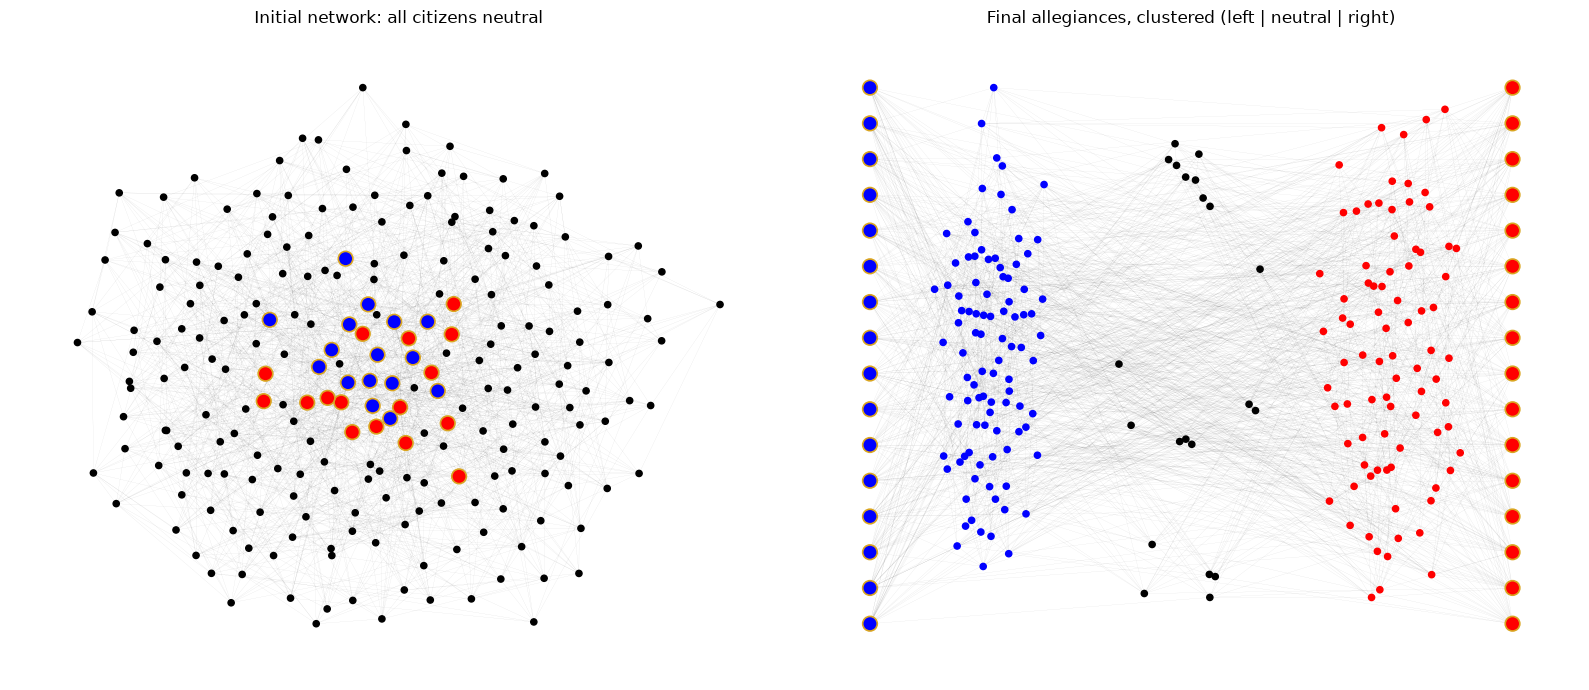

In [3]:
initial = build_network(config.N, config.D, config.IL, config.IR,
                        config.DL, config.DR, config.PL, config.PR,
                        config.SM, config.SD, seed=config.SEED)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw_network(initial, config.N, ax=axes[0], seed=0,
             title='Initial network: all citizens neutral')
draw_network(result.graph, config.N, ax=axes[1], clustered=True, seed=0,
             title='Final allegiances, clustered (left | neutral | right)')
plt.tight_layout()
plt.show()

Blue = left, black = neutral, red = right. The larger, gold-ringed nodes are the influencers, pinned at the outer edges of their side in the clustered view.

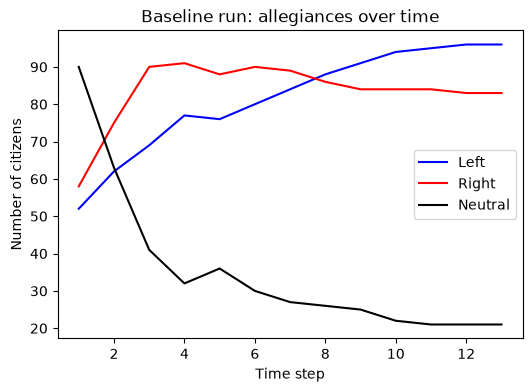

In [4]:
plot_history(result.history, title='Baseline run: allegiances over time')
plt.show()

## Campaign experiments

Starting from a toy parameter set that gives an even outcome, we raise one parameter of the *right* side's campaign at a time by 20% — its persuasiveness (PR), its number of influencers (IR), or its influencers' reach (DR) — and watch how the final allegiances shift.

Same Conditions Plot: converged at step 11, (left, right, neutral) = (82, 77, 41)
Effect of More Persuasiveness: converged at step 8, (left, right, neutral) = (0, 200, 0)
Effect of More Number of Influencers: converged at step 12, (left, right, neutral) = (0, 200, 0)
Effect of More Popular Influencers: converged at step 10, (left, right, neutral) = (13, 163, 24)


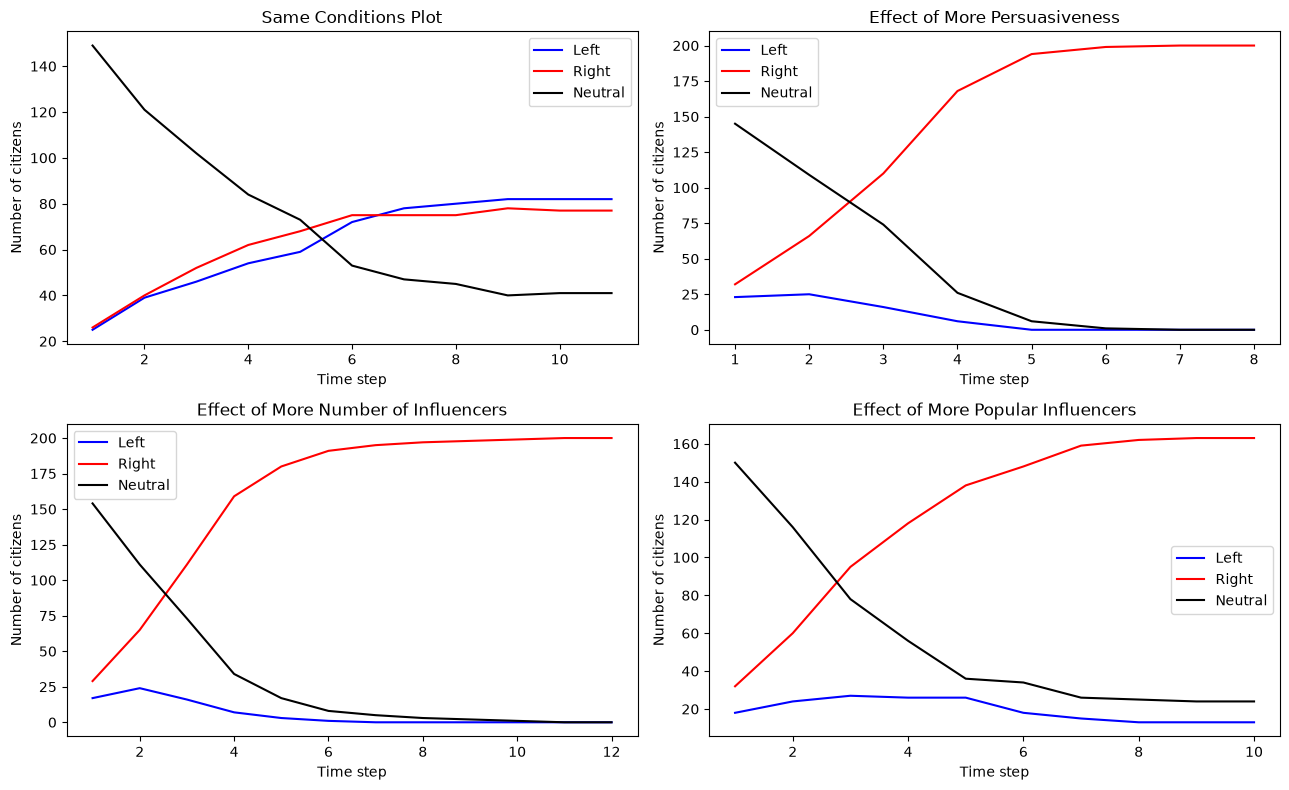

In [5]:
base = dict(N=200, D=10, IL=10, IR=10, DL=25, DR=25,
            PL=-5, PR=5, SM=10, SD=3)
# a seed under which the identical-campaigns baseline lands even,
# so the one-sided tweaks below are visible against it
SCENARIO_SEED = 6
scenarios = {
    'Same Conditions Plot': {},
    'Effect of More Persuasiveness': {'PR': 6},
    'Effect of More Number of Influencers': {'IR': 12},
    'Effect of More Popular Influencers': {'DR': 30},
}

results = {}
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (title, tweak) in zip(axes.flat, scenarios.items()):
    res = simulate(**{**base, **tweak}, seed=SCENARIO_SEED)
    results[title] = res
    plot_history(res.history, ax=ax, title=title)
    print(f'{title}: converged at step {res.converged_at}, '
          f'(left, right, neutral) = {res.final_counts}')
plt.tight_layout()
plt.show()

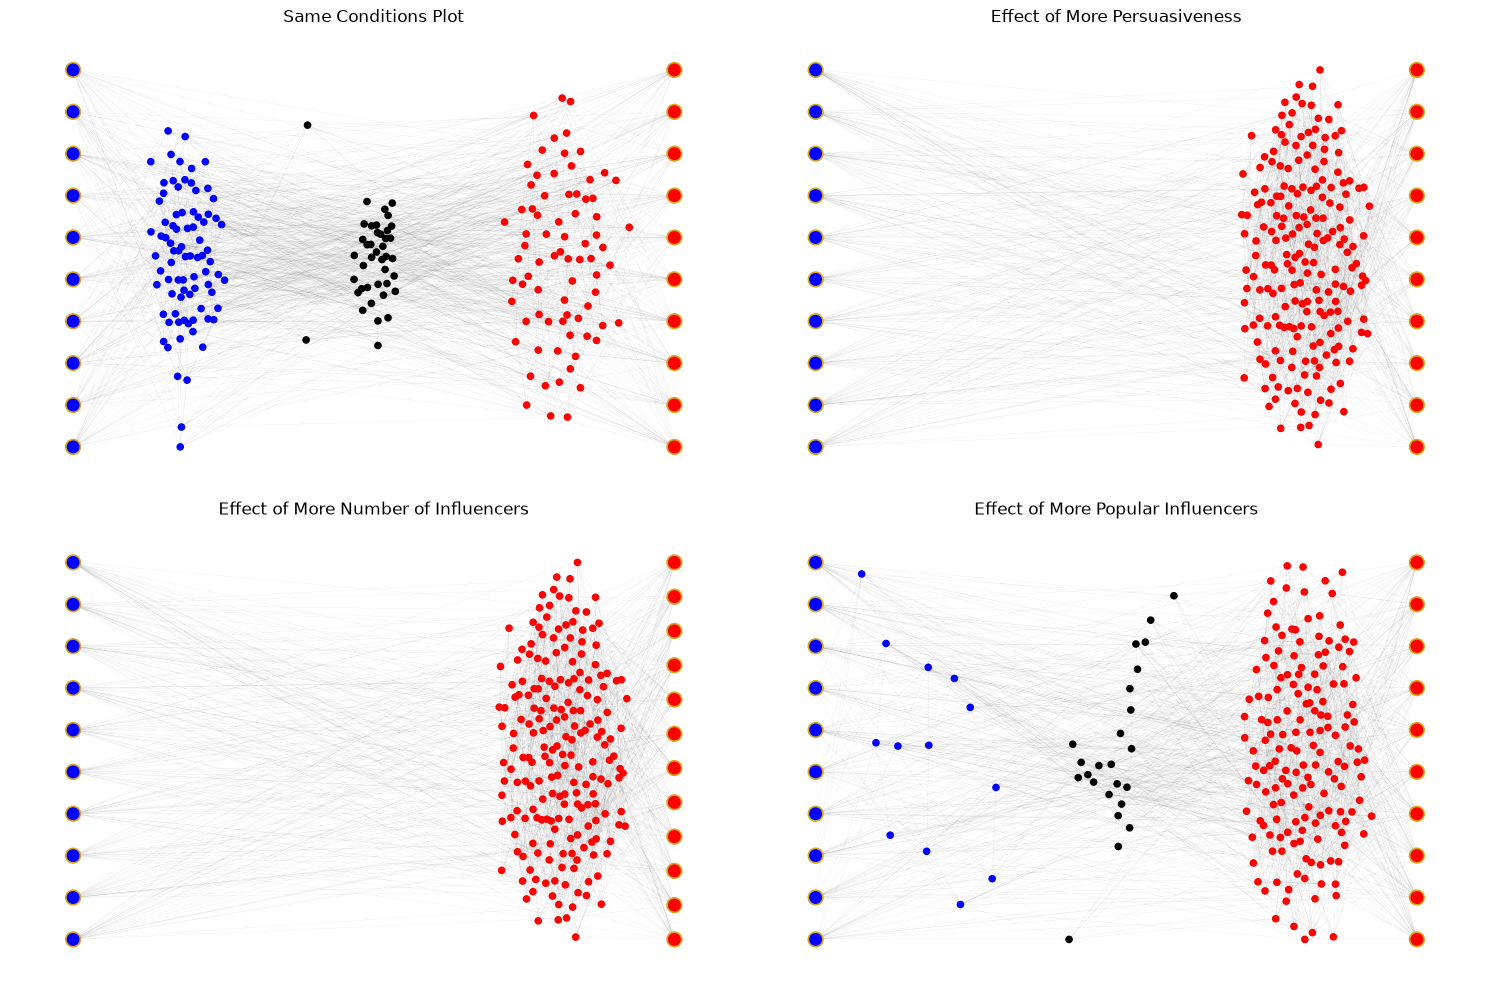

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (title, res) in zip(axes.flat, results.items()):
    draw_network(res.graph, base['N'], ax=ax, clustered=True, seed=0,
                 title=title)
plt.tight_layout()
plt.show()

Even a 20% edge in a single campaign parameter visibly tilts the final split — the advantage compounds as every newly convinced citizen re-broadcasts the campaign to their own contacts.